# 24b - StarDist receptive field (plain StarDist API)

Same logic as notebook 24, with **no scikit-ops, no appose worker and no tnia**.
Everything runs in this kernel against the StarDist API directly, so it can be
run in any environment that has `stardist`, `tensorflow` and `csbdeep`.

Written to compare timing against notebook 24. Each epoch prints its own
wall-clock seconds.

In [2]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Ask TF for the memory it uses rather than the whole card. Must happen before
# any GPU work; TF refuses to change it once the device is initialised.
for _gpu in tf.config.list_physical_devices('GPU'):
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError:
        pass

import stardist
from stardist.models import Config2D, StarDist2D
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries

import circles

print('stardist  ', stardist.__version__)
print('tensorflow', tf.__version__)
print('GPUs      ', tf.config.list_physical_devices('GPU'))

try:
    import gputools
    print('gputools  ', gputools.__version__, '-> star_dist can use OpenCL')
except ImportError:
    print('gputools   MISSING -> star_dist uses the C extension on CPU')

stardist   0.8.5
tensorflow 2.10.1
GPUs       [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


persistent_dict.py (52): Unable to import recommended hash 'siphash24.siphash13', falling back to 'hashlib.sha256'. Run 'python3 -m pip install siphash24' to install the recommended hash.


If you want to compute separable approximations, please install it with
pip install scikit-tensor-py3
gputools   0.2.15 -> star_dist can use OpenCL


## How fast is `star_dist` here?

Target generation, not the conv-net, is what dominates a StarDist epoch at
`grid=(1,1)`. This is the number to compare between machines.

`cpu/wall` near 1.0 means the C extension is running on a single core; near the
core count means OpenMP is working.

In [3]:
from stardist import star_dist

_rng = np.random.default_rng(0)
_lbl = np.zeros((256, 256), np.uint16)
_yy, _xx = np.mgrid[:256, :256]
for _i in range(12):
    _cy, _cx, _r = _rng.integers(30, 226), _rng.integers(30, 226), _rng.integers(5, 40)
    _lbl[(_yy - _cy) ** 2 + (_xx - _cx) ** 2 < _r * _r] = _i + 1

star_dist(_lbl, 32, mode='cpp')                       # warm up
_w, _c = time.time(), time.process_time()
for _ in range(5):
    star_dist(_lbl, 32, mode='cpp')
_w, _c = time.time() - _w, time.process_time() - _c
print('star_dist cpp     %6.1f ms/call   cpu/wall %5.2f   cores %d'
      % (_w / 5 * 1000, _c / _w, os.cpu_count()))

try:
    star_dist(_lbl, 32, mode='opencl')
    _w = time.time()
    for _ in range(5):
        star_dist(_lbl, 32, mode='opencl')
    print('star_dist opencl  %6.1f ms/call' % ((time.time() - _w) / 5 * 1000))
except Exception as _e:
    print('star_dist opencl  unavailable:', type(_e).__name__)

star_dist cpp       68.5 ms/call   cpu/wall 27.05   cores 28
star_dist opencl    12.8 ms/call


In [4]:
RADII = [3, 5, 15, 30, 60, 70]
test_img, test_lbl = circles.calibration(RADII)

DIAMETERS = [2 * r for r in RADII]
print('test image', test_img.shape, 'diameters', DIAMETERS)

test image (256, 534) diameters [6, 10, 30, 60, 120, 140]


## Measure the receptive field

Send one bright pixel through the network. How far the response spreads is what
the network can see. Performance of the network will be constrained by how many
pixels it can see.

In [5]:
from scipy.ndimage import zoom


def receptive_field(grid_size_xy=1, unet_n_depth=3, unet_kernel_size=3,
                    n_channel_in=1, img_size=512):
    '''The impulse response of an untrained StarDist 2D network, as an image.

    The absolute difference between the network's output for a single bright
    central pixel and its output for an empty image: non-zero exactly where
    information from that pixel reached.
    '''
    if img_size & (img_size - 1):
        raise ValueError('img_size must be a power of two, not %d' % img_size)

    # Otherwise every network measured stays resident in the TF graph.
    tf.keras.backend.clear_session()

    net = StarDist2D(
        config=Config2D(
            n_rays=32,
            axes='YXC',
            n_channel_in=n_channel_in,
            grid=(grid_size_xy, grid_size_xy),
            unet_n_depth=unet_n_depth,
            unet_kernel_size=(unet_kernel_size, unet_kernel_size),
        ),
        name=None,
        basedir=None,
    )

    shape = (img_size, img_size)
    mid = tuple(s // 2 for s in shape)
    x = np.zeros((1,) + shape + (n_channel_in,), dtype=np.float32)
    z = np.zeros_like(x)
    x[(0,) + mid + (slice(None),)] = 1

    y = net.keras_model.predict(x, verbose=0)[0][0, ..., 0]
    y0 = net.keras_model.predict(z, verbose=0)[0][0, ..., 0]

    grid = tuple((np.array(shape) / np.array(y.shape)).astype(int))
    response = np.abs(zoom(y, grid, order=0) - zoom(y0, grid, order=0))

    reached = response > 0
    if (reached[0].any() or reached[-1].any()
            or reached[:, 0].any() or reached[:, -1].any()):
        raise ValueError(
            'The response reaches the border of a %dpx test image, so the '
            'receptive field is at least that wide. Raise img_size.' % img_size)

    del net
    tf.keras.backend.clear_session()
    return response.astype(np.float32)


def extent(response):
    '''The height and width, in pixels, that an impulse response covers.'''
    reached = np.asarray(response) > 0
    if not reached.any():
        return (0, 0)
    rows, cols = np.where(reached)
    return (int(rows.max() - rows.min() + 1), int(cols.max() - cols.min() + 1))

In [6]:
# Barely any depth, so a very small field on purpose.
SMALL_GRID, SMALL_DEPTH = 1, 1
BIG_GRID, BIG_DEPTH = 1, 4

small_net_field = min(extent(receptive_field(
    grid_size_xy=SMALL_GRID, unet_n_depth=SMALL_DEPTH,
    n_channel_in=1, img_size=512)))
print(f'grid={SMALL_GRID} depth={SMALL_DEPTH} -> {small_net_field} px')

Using default values: prob_thresh=0.5, nms_thresh=0.4.
grid=1 depth=1 -> 20 px


In [7]:
# Four levels deep, so the field covers the biggest circle.
big_net_field = min(extent(receptive_field(
    grid_size_xy=BIG_GRID, unet_n_depth=BIG_DEPTH,
    n_channel_in=1, img_size=512)))
print(f'grid={BIG_GRID} depth={BIG_DEPTH} -> {big_net_field} px')

Using default values: prob_thresh=0.5, nms_thresh=0.4.
grid=1 depth=4 -> 181 px


In [8]:
small = f'small net (rf={small_net_field})'
big = f'big net (rf={big_net_field})'
print(f'{"diameter":>17} {small:>19} {big:>21}')
for d in DIAMETERS:
    print(f'{d:>17} {"sees it" if small_net_field >= d else "too small":>19} '
          f'{"sees it" if big_net_field >= d else "too small":>21}')

         diameter   small net (rf=20)      big net (rf=181)
                6             sees it               sees it
               10             sees it               sees it
               30           too small               sees it
               60           too small               sees it
              120           too small               sees it
              140           too small               sees it


## See it on the circles

The red square is what the network sees. Both squares are drawn on the biggest
circle.

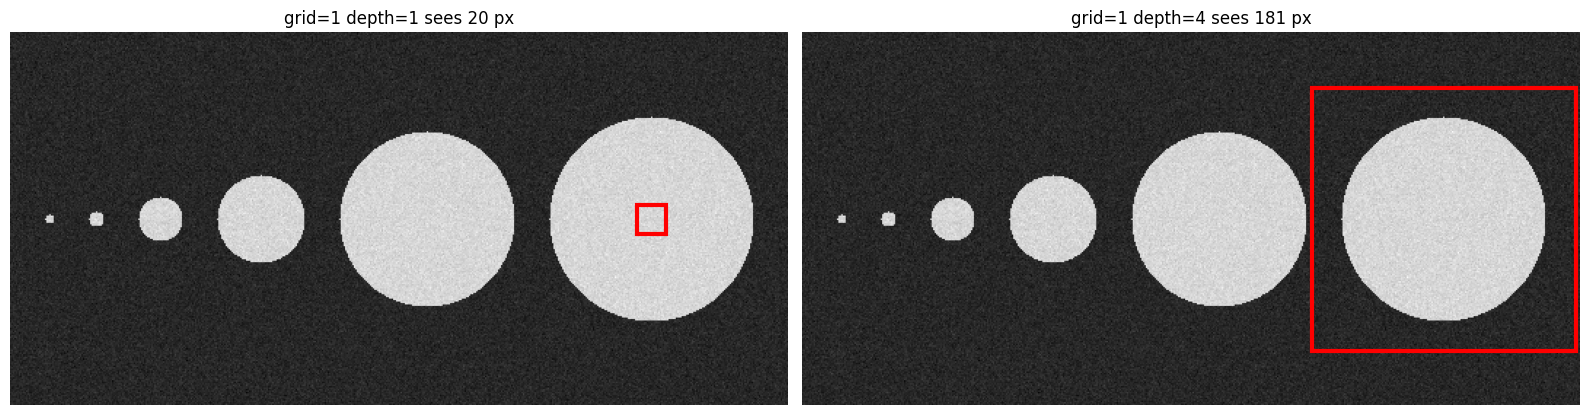

In [9]:
from matplotlib.patches import Rectangle

cy, cx = test_img.shape[0] // 2, test_img.shape[1] - 24 - RADII[-1]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for a, field, name in [
    (ax[0], small_net_field, f'grid={SMALL_GRID} depth={SMALL_DEPTH}'),
    (ax[1], big_net_field, f'grid={BIG_GRID} depth={BIG_DEPTH}'),
]:
    a.imshow(test_img, cmap='gray')
    a.add_patch(Rectangle((cx - field / 2, cy - field / 2), field, field,
                          fill=False, edgecolor='red', linewidth=3))
    a.set_title(f'{name} sees {field} px')
    a.axis('off')
plt.tight_layout()
plt.show()

## Training data: random circles

Radii from 1 to 85, random positions, eight images. The test radii are not
these, so nothing can be memorised.

Unlike notebook 24 these stay in memory - there is no worker to hand file paths
to, so the tiff round-trip serves no purpose here.

In [10]:
def outline_overlay(image, labels, color=(1.0, 0.0, 0.0)):
    '''Grayscale image as RGB with label boundaries drawn on top.'''
    img = np.asarray(image, dtype=np.float32)
    lo, hi = float(img.min()), float(img.max())
    img = (img - lo) / (hi - lo) if hi > lo else np.zeros_like(img)
    rgb = np.dstack([img] * 3)
    rgb[find_boundaries(labels, mode='outer')] = color
    return rgb


train_imgs, train_lbls = circles.random(8, size=256, min_r=1, max_r=85, seed=1)

# Validate on the training data. val_loss then tracks training fit, which is
# what drives the learning rate schedule and picks the saved weights.
X = [np.asarray(im, np.float32)[..., np.newaxis] for im in train_imgs]
Y = [np.asarray(lb, np.int32) for lb in train_lbls]

X_train, Y_train = X + X, Y + Y     # 16 pairs, as notebook 24 builds
X_val, Y_val = X, Y                 # the 8 held out are the same 8

WORK = Path(os.path.expanduser('~')) / 'i2k_circles_24b'
(WORK / 'models').mkdir(parents=True, exist_ok=True)

print(len(X), 'pairs,', sum(int(l.max()) for l in train_lbls), 'circles')
print('work dir', WORK)

8 pairs, 103 circles
work dir C:\Users\bnort\i2k_circles_24b


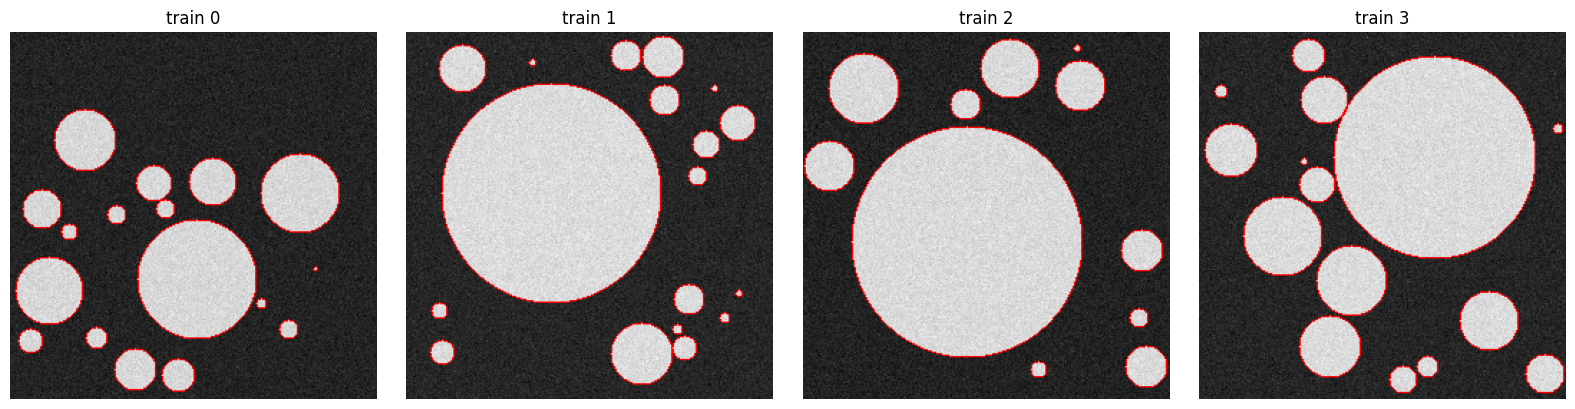

In [11]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    ax[i].imshow(outline_overlay(train_imgs[i], train_lbls[i]))
    ax[i].set_title(f'train {i}')
    ax[i].axis('off')
plt.tight_layout()
plt.show()

## Train

`EPOCHS` and `STEPS` match notebook 24. Lower them to get a timing number
quickly - seconds per epoch is what matters for the comparison, not the
finished model.

In [12]:
EPOCHS = 100
STEPS = 50
PATCH = 256
BATCH = 1


def train(name, grid_size_xy, unet_n_depth, epochs=EPOCHS, steps_per_epoch=STEPS):
    '''Train one StarDist2D model. Returns (model_dir, median s/epoch).'''
    tf.keras.backend.clear_session()

    config = Config2D(
        n_rays=32,
        axes='YXC',
        n_channel_in=1,
        train_patch_size=(PATCH, PATCH),
        train_batch_size=BATCH,
        unet_n_depth=unet_n_depth,
        grid=(grid_size_xy, grid_size_xy),
    )
    net = StarDist2D(config=config, name=name, basedir=str(WORK / 'models'))
    #net.prepare_for_training()

    #timer = EpochTimer()
    #net.callbacks.append(timer)

    # Keras' own bar would interleave with the timer, and StarDist hardcodes
    # verbose=1, so force it off at the one call it reaches.
    #_fit = net.keras_model.fit
    #net.keras_model.fit = lambda *a, **kw: _fit(*a, **{**kw, 'verbose': 0})

    #print('== %s: grid=%d depth=%d patch=%d batch=%d %d steps =='
    #      % (name, grid_size_xy, unet_n_depth, PATCH, BATCH, steps_per_epoch),
    #      flush=True)
    #t0 = time.time()
    net.train(X_train, Y_train, validation_data=(X_val, Y_val),
              epochs=epochs, steps_per_epoch=steps_per_epoch)
    #total = time.time() - t0

    steady = timer.times[1:] or timer.times      # drop epoch 1 (graph build)
    print('-> total %.1f s   median %.2f s/epoch' % (total, float(np.median(steady))))
    return str(WORK / 'models' / name), float(np.median(steady))

In [13]:
small_net, small_spe = train('small_net_24b', SMALL_GRID, SMALL_DEPTH)
print(small_net)

base_model.py (203): output path for model already exists, files may be overwritten: C:\Users\bnort\i2k_circles_24b\models\small_net_24b


Using default values: prob_thresh=0.5, nms_thresh=0.4.
Epoch 1/100
50/50 [==============================] - 13s 212ms/step - loss: 9.1722 - prob_loss: 0.4451 - dist_loss: 43.6354 - prob_kld: 0.2777 - dist_relevant_mae: 43.6353 - dist_relevant_mse: 2865.6543 - dist_dist_iou_metric: 0.0042 - val_loss: 7.8864 - val_prob_loss: 0.2810 - val_dist_loss: 38.0268 - val_prob_kld: 0.1135 - val_dist_relevant_mae: 38.0264 - val_dist_relevant_mse: 2375.9194 - val_dist_dist_iou_metric: 0.0605 - lr: 3.0000e-04
Epoch 2/100
50/50 [==============================] - 10s 203ms/step - loss: 5.6363 - prob_loss: 0.2305 - dist_loss: 27.0290 - prob_kld: 0.0631 - dist_relevant_mae: 27.0276 - dist_relevant_mse: 1216.5549 - dist_dist_iou_metric: 0.2602 - val_loss: 5.1895 - val_prob_loss: 0.2050 - val_dist_loss: 24.9223 - val_prob_kld: 0.0375 - val_dist_relevant_mae: 24.9209 - val_dist_relevant_mse: 1081.1423 - val_dist_dist_iou_metric: 0.2901 - lr: 3.0000e-04
Epoch 3/100
50/50 [==============================] - 10

NameError: name 'timer' is not defined

In [ ]:
big_net, big_spe = train('big_net_24b', BIG_GRID, BIG_DEPTH)
print(big_net)

## Predict on the test image

Six circles, sizes it never saw, from 6 px to 140 px.

No normalization - the training data was never normalized either, so this
matches notebook 24's `normalize=False`.

In [ ]:
def predict(model_dir, image, prob_thresh=0.5, nms_thresh=0.4):
    '''Load a model from disk and segment one plane. No normalization.'''
    tf.keras.backend.clear_session()
    basedir, name = os.path.split(os.path.normpath(model_dir))
    net = StarDist2D(None, name=name, basedir=basedir)
    labels, _ = net.predict_instances(np.asarray(image, np.float32),
                                      prob_thresh=prob_thresh,
                                      nms_thresh=nms_thresh)
    return np.asarray(labels).astype(np.uint16)


by_small_net = predict(small_net, test_img)
by_big_net = predict(big_net, test_img)

fig, ax = plt.subplots(3, 1, figsize=(13, 13))
for a, lbl, title in [
    (ax[0], test_lbl, f'truth ({test_lbl.max()})'),
    (ax[1], by_small_net, f'small net ({by_small_net.max()})'),
    (ax[2], by_big_net, f'big net ({by_big_net.max()})'),
]:
    a.imshow(outline_overlay(test_img, lbl))
    a.set_title(title)
    a.axis('off')
plt.tight_layout()
plt.show()

## Measured size against true size

This is the point. A network that cannot see the edge has to guess the size.

In [ ]:
truth_props = {p.label: p for p in regionprops(test_lbl)}

fig, a = plt.subplots(figsize=(6, 6))
for pred, name, style in [(by_small_net, 'small net', 'o'),
                          (by_big_net, 'big net', 's')]:
    found = {p.label: p.equivalent_diameter_area for p in regionprops(pred)}
    xs, ys = [], []
    for label, p in truth_props.items():
        y, x = (int(v) for v in p.centroid)
        hit = pred[y, x]
        if hit:
            xs.append(p.equivalent_diameter_area)
            ys.append(found[hit])
    a.plot(xs, ys, style, label=name, markersize=9)

a.plot([0, 150], [0, 150], 'k--', linewidth=1, label='perfect')
a.set_xlabel('true diameter (px)')
a.set_ylabel('measured diameter (px)')
a.legend()
plt.show()

## Timing summary

The number to carry to the other machine.

In [ ]:
print('stardist %s   tensorflow %s' % (stardist.__version__, tf.__version__))
print('GPU      %s' % (tf.config.list_physical_devices('GPU') or 'NONE'))
print('cores    %d' % os.cpu_count())
print()
print('small net (grid=%d depth=%d)  %6.2f s/epoch'
      % (SMALL_GRID, SMALL_DEPTH, small_spe))
print('big net   (grid=%d depth=%d)  %6.2f s/epoch'
      % (BIG_GRID, BIG_DEPTH, big_spe))
print()
print('at %d steps/epoch, patch %d, batch %d' % (STEPS, PATCH, BATCH))

## What to take away

Match the field to the object. A field smaller than the object cannot see the
edges, so it guesses the size instead of measuring it.